In [ ]:
#Amit pawar
#25070126501
@title
Naive Bayes Classifier use a Heart Disease Dataset.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,precision_score,
    recall_score,
    f1_score,roc_auc_score,
    roc_curve
)
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
import pandas as pd
dataset = pd.read_csv('/content/heart disease dataset_0ada84063cf78a2e598ac85ddb2ba953.csv')
dataset.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

le = LabelEncoder()
X[:,0] = le.fit_transform(X[:,0])

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
y_pred_dummy = dummy.predict(x_test)
baseline_accuracy = accuracy_score(y_test, y_pred_dummy)
print(f"Baseline Accuracy: {baseline_accuracy}")

Baseline Accuracy: 0.5136186770428015


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nb_model = GaussianNB()
nb_model.fit(x_train,y_train)

y_pred_nb = nb_model.predict(x_test)

print("Accuracy:",accuracy_score(y_test,y_pred_nb))
print("Precision:",precision_score(y_test,y_pred_nb))
print("Recall:",recall_score(y_test,y_pred_nb))
print("F1 score:" ,f1_score(y_test,y_pred_nb))

Accuracy: 0.8404669260700389
Precision: 0.8321167883211679
Recall: 0.8636363636363636
F1 score: 0.8475836431226765


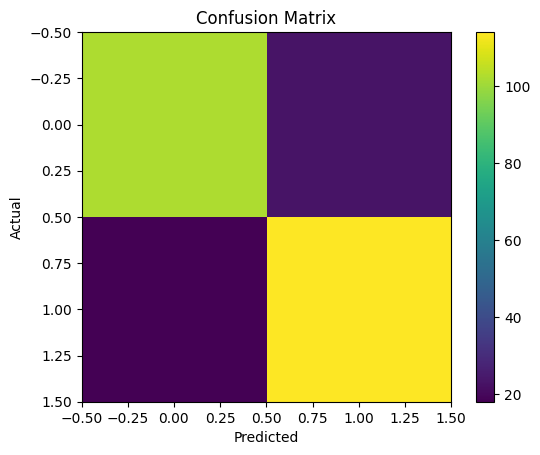

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_pred_nb)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

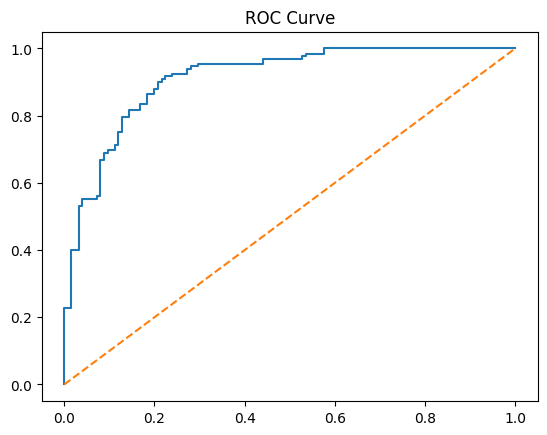

AUC:  0.9121212121212121


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = nb_model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test,y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve")
plt.show()
print("AUC: ",roc_auc)

1️⃣ What this Graph Represents

This graph shows how the Naive Bayes algorithm separates two classes using Age and Salary features.

X-axis: Age (scaled)

Y-axis: Salary (scaled)

Each dot = one data point (person)

The model predicts whether a person belongs to Class 0 or Class 1.

2️⃣ Meaning of Colors

There are two types of dots:

🟣 Purple dots → Class 0 (example: Not buying product / No)

🟡 Yellow dots → Class 1 (example: Buying product / Yes)

Each dot represents one observation from the dataset.

3️⃣ Background Colors (Decision Regions)

The background color shows the prediction made by the Naive Bayes model.

Light purple region → Model predicts Class 0

Light yellow region → Model predicts Class 1

So if a new data point falls:

in purple area → predicted Class 0

in yellow area → predicted Class 1

4️⃣ Decision Boundary

The curved line between the colors is called the Decision Boundary.

It means:

The boundary where the probability of both classes is equal.

Naive Bayes calculates probability using Bayes Theorem:

𝑃 ( 𝐴 ∣ 𝐵 )
𝑃 ( 𝐵 ∣ 𝐴 ) 𝑃 ( 𝐴 ) 𝑃 ( 𝐵 ) P(A∣B)= P(B) P(B∣A)P(A)​

The model chooses the class with the highest probability.

5️⃣ Why the Boundary is Curved

Naive Bayes assumes features follow a Gaussian (Normal) Distribution.

Because of this, the decision boundary becomes curved instead of a straight line.



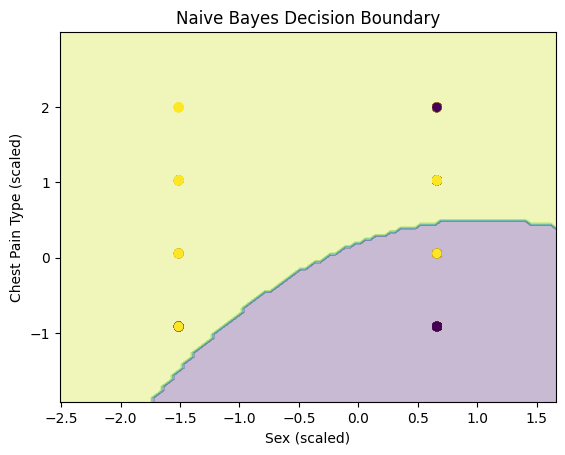

In [ ]:
import numpy as np

x_vis = X[:,1:3]

nb_vis = GaussianNB()
nb_vis.fit(x_vis,y)

#create grid
x_range = np.linspace(x_vis[:,0].min()-1,x_vis[:,0].max()+1,100)
y_range = np.linspace(x_vis[:,1].min()-1,x_vis[:,1].max()+1,100)

xx, yy=np.meshgrid(x_range,y_range)
grid = np.c_[xx.ravel(),yy.ravel()]

plt.contourf(xx,yy,nb_vis.predict(grid).reshape(xx.shape),alpha=0.3)
plt.scatter(x_vis[:,0],x_vis[:,1],c=y)

plt.xlabel("Sex (scaled)")
plt.ylabel("Chest Pain Type (scaled)")
plt.title("Naive Bayes Decision Boundary")
plt.show()